# Manipulator (acrobot) — three-method comparison figures (one-shot)

Regenerates the acrobot paper figures comparing **vanilla MPC**, **reach-avoid MPC
(RA-MPC)** and the **unconstrained controller** (k1 backstepping), reusing the exact
settings of the three `example_manipulator_*` notebooks.

Figures -> `figures/` as `.pdf` + `.png`:

- `fig_manip_vanilla`, `fig_manip_rampc`, `fig_manip_uncon` — per method: feasible region
  (end-effector y-space) + the single closed-loop trajectory from a shared initial point.
- `fig_manip_compare` — RA-MPC success rate vs sampling time + torque comparison
  (unconstrained vs RA-MPC) from the shared initial point.

**Feasibility (end-effector reaches the target safely):** vanilla MPC = target-terminal MPC
solvable (N=20, dt=0.01 -> 0.2 s horizon); RA-MPC = receding closed loop (cert terminal,
continuous-ZOH) reaches the target within 10 s; **unconstrained = certified region {cert>=0}**
(its k1 closed loop reaches only glacially, so the certified set is the meaningful notion).

Run with the **rab_mpc** kernel. The RA-MPC feasibility + dt sweep are slow; results cached.


In [34]:
# -- Repo-root bootstrap -------------------------------------------------------
import os
import sys

ROOT = os.getcwd()
for _ in range(4):
    if os.path.isdir(os.path.join(ROOT, "controllers")) and os.path.isdir(
        os.path.join(ROOT, "matlab")
    ):
        break
    ROOT = os.path.dirname(ROOT)
for _sub in ("controllers", "python"):
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)
OUTDIR = os.path.join(ROOT, "figures")
os.makedirs(OUTDIR, exist_ok=True)
print("ROOT  =", ROOT, "| OUTDIR =", OUTDIR)

ROOT  = /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC | OUTDIR = /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC/figures


In [35]:
# -- Parameters ---------------------------------------------------------------
import matplotlib.pyplot as plt

X0_SHARED = None  # length-4 [q1,q2,dq1,dq2]; None -> auto-pick
RECOMPUTE_FEAS = False
N_CANDIDATES = 100
N_SWEEP_CAND = 40  # smaller subset for the (slow) dt sweep
SEED = 42
DT_SWEEP = [0.005, 0.01, 0.02, 0.04]  # N = round(0.2/dt) = [40, 20, 10, 5]

In [36]:
# -- Setup: dynamics, sets, controllers, MPC, feasibility, rollouts ----------
import numpy as np
import sympy as sp
import casadi as ca
from scipy.integrate import solve_ivp


from acrobot_inverse_kinematics import inverse_kinematics
from sop_bounded_control_acrobot_result import (
    certificate_opt as cert_ra_sym,
    k1_opt as k1_ra,
)
from sop_bounded_control_acrobot_unconstrained import (
    k1_opt as k1_unc,
    u_opt as _u_unc_sym,
    certificate_opt as _cert_unc_sym,
)

# ── Symbols / physical params ────────────────────────────────────────────────
x1, x2, x3, x4 = sp.symbols("x1 x2 x3 x4")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, x3, x4]
m1, m2, l1, l2, lc1, lc2, I1, I2, g_grav = (
    1.0,
    1.0,
    4.0,
    4.0,
    2.0,
    2.0,
    0.02,
    0.02,
    9.81,
)
TARGET_POS = np.array([5.8, 1.9])
u1_max, u2_max = 680.0, 500.0  # per-channel torque bounds (tau1, tau2) [N·m]
DT_BASE, N_BASE, T_HOR = 0.01, 20, 0.20
T_MAX = 10.0  # MPC reach window
T_MAX_UNC = 20.0  # unconstrained closed-loop window (glacial k1)
sin_min = 0.15

# ── Acrobot dynamics (sympy) ─────────────────────────────────────────────────
M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * sp.cos(x2))
M12 = m2 * (lc2**2 + l1 * lc2 * sp.cos(x2)) + I2
M_sym = sp.Matrix([[M11, M12], [M12, m2 * lc2**2 + I2]])
Minv = M_sym.inv()
C_sym = sp.Matrix(
    [
        [-m2 * l1 * lc2 * sp.sin(x2) * x4, -m2 * l1 * lc2 * sp.sin(x2) * (x3 + x4)],
        [m2 * l1 * lc2 * sp.sin(x2) * x3, 0],
    ]
)
G_sym = sp.Matrix(
    [
        (m1 * g_grav * lc1 + m2 * g_grav * l1) * sp.cos(x1)
        + m2 * g_grav * lc2 * sp.cos(x1 + x2),
        m2 * g_grav * lc2 * sp.cos(x1 + x2),
    ]
)
f_sym = sp.Matrix([x3, x4]).col_join(Minv @ (-C_sym @ sp.Matrix([x3, x4]) - G_sym))
g_mat = sp.Matrix([[0, 0], [0, 0]]).col_join(Minv)
hx = sp.Matrix(
    [l1 * sp.cos(x1) + l2 * sp.cos(x1 + x2), l1 * sp.sin(x1) + l2 * sp.sin(x1 + x2)]
)
psi_y = -((4 * (y1 - 2) - 2 * y2**3) ** 2) + 0.8 * y2**3 + 10
phi_y = ((y1 - 2 - 3.5) ** 2 / 1.2**2) + ((y2 - 1.8) ** 2 / 0.4**2) - 2
psi_x = psi_y.subs({y1: hx[0], y2: hx[1]})
phi_x = phi_y.subs({y1: hx[0], y2: hx[1]})

psi_x_func = sp.lambdify(state_vars, psi_x, "numpy")
phi_x_func = sp.lambdify(state_vars, phi_x, "numpy")
psi_y_func = sp.lambdify([y1, y2], psi_y, "numpy")
phi_y_func = sp.lambdify([y1, y2], phi_y, "numpy")
hx_func = sp.lambdify(state_vars, hx, "numpy")
cert_ra_func = sp.lambdify(state_vars, cert_ra_sym, "numpy")


def acrobot_rhs_np(t, x_, u_):
    q1, q2, dq1, dq2 = x_
    M = np.array(
        [
            [
                I1
                + I2
                + m1 * lc1**2
                + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * np.cos(q2)),
                m2 * (lc2**2 + l1 * lc2 * np.cos(q2)) + I2,
            ],
            [m2 * (lc2**2 + l1 * lc2 * np.cos(q2)) + I2, m2 * lc2**2 + I2],
        ]
    )
    C = np.array(
        [
            [
                -m2 * l1 * lc2 * np.sin(q2) * dq2,
                -m2 * l1 * lc2 * np.sin(q2) * (dq1 + dq2),
            ],
            [m2 * l1 * lc2 * np.sin(q2) * dq1, 0.0],
        ]
    )
    G = np.array(
        [
            (m1 * g_grav * lc1 + m2 * g_grav * l1) * np.cos(q1)
            + m2 * g_grav * lc2 * np.cos(q1 + q2),
            m2 * g_grav * lc2 * np.cos(q1 + q2),
        ]
    )
    qddot = np.linalg.solve(M, -C @ np.array([dq1, dq2]) - G + np.asarray(u_))
    return [dq1, dq2, qddot[0], qddot[1]]


# ── Unconstrained controller = synthesized unconstrained reach-avoid law ──────
#    sop_bounded_control_acrobot_unconstrained.u_opt (same law validated in
#    example_manipulator_unconstrained_reach_avoid.ipynb)
_u_unc = sp.Matrix(_u_unc_sym)
dyn_unc_f = sp.lambdify(state_vars, f_sym + g_mat @ _u_unc, "numpy", cse=True)
u_unc_f = sp.lambdify(state_vars, list(_u_unc), "numpy", cse=True)

# Unconstrained controller's OWN reach-avoid certificate (synthesized):
cert_unc_sym = sp.sympify(_cert_unc_sym)
cert_unc_func = sp.lambdify(state_vars, cert_unc_sym, "numpy")

# ── CasADi dynamics + MPC ────────────────────────────────────────────────────
_cx = [ca.SX.sym(n) for n in ("x1", "x2", "x3", "x4")]
_smap = {x1: _cx[0], x2: _cx[1], x3: _cx[2], x4: _cx[3]}


def _s2c(e, mp):
    if isinstance(
        e,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
            sp.core.numbers.Pi,
        ),
    ):
        return float(e)
    if isinstance(e, sp.Symbol):
        return mp[e]
    if isinstance(e, sp.Add):
        return sum(_s2c(a, mp) for a in e.args)
    if isinstance(e, sp.Mul):
        r = 1.0
        for a in e.args:
            r = r * _s2c(a, mp)
        return r
    if isinstance(e, sp.Pow):
        return _s2c(e.args[0], mp) ** _s2c(e.args[1], mp)
    if isinstance(e, sp.sin):
        return ca.sin(_s2c(e.args[0], mp))
    if isinstance(e, sp.cos):
        return ca.cos(_s2c(e.args[0], mp))
    if isinstance(e, sp.Number):
        return float(e)
    raise ValueError(type(e))


cert_ca_f = ca.Function("cert", _cx, [_s2c(cert_ra_sym, _smap)])
_xc = ca.MX.sym("x", 4)
_uc = ca.MX.sym("u", 2)


def _acro_ca(x, u):
    q1, q2, dq1, dq2 = x[0], x[1], x[2], x[3]
    M = ca.vertcat(
        ca.horzcat(
            I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * ca.cos(q2)),
            m2 * (lc2**2 + l1 * lc2 * ca.cos(q2)) + I2,
        ),
        ca.horzcat(m2 * (lc2**2 + l1 * lc2 * ca.cos(q2)) + I2, m2 * lc2**2 + I2),
    )
    C = ca.vertcat(
        ca.horzcat(
            -m2 * l1 * lc2 * ca.sin(q2) * dq2, -m2 * l1 * lc2 * ca.sin(q2) * (dq1 + dq2)
        ),
        ca.horzcat(m2 * l1 * lc2 * ca.sin(q2) * dq1, ca.DM(0.0)),
    )
    G = ca.vertcat(
        (m1 * g_grav * lc1 + m2 * g_grav * l1) * ca.cos(q1)
        + m2 * g_grav * lc2 * ca.cos(q1 + q2),
        m2 * g_grav * lc2 * ca.cos(q1 + q2),
    )
    qddot = ca.solve(M, -C @ ca.vertcat(dq1, dq2) - G + u)
    return ca.vertcat(dq1, dq2, qddot[0], qddot[1])


_rhs_ca = ca.Function("f", [_xc, _uc], [_acro_ca(_xc, _uc)])


def _h_ca(xv):
    return ca.vertcat(
        l1 * ca.cos(xv[0]) + l2 * ca.cos(xv[0] + xv[1]),
        l1 * ca.sin(xv[0]) + l2 * ca.sin(xv[0] + xv[1]),
    )


def _safe_ca(xv):
    y1v = l1 * ca.cos(xv[0]) + l2 * ca.cos(xv[0] + xv[1])
    y2v = l1 * ca.sin(xv[0]) + l2 * ca.sin(xv[0] + xv[1])
    return -((4 * (y1v - 2) - 2 * y2v**3) ** 2) + 0.8 * y2v**3 + 10


def _target_ca(xv):
    y1v = l1 * ca.cos(xv[0]) + l2 * ca.cos(xv[0] + xv[1])
    y2v = l1 * ca.sin(xv[0]) + l2 * ca.sin(xv[0] + xv[1])
    return ((y1v - 5.5) ** 2 / 1.2**2) + ((y2v - 1.8) ** 2 / 0.4**2) - 2


_IPOPT = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 500,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}
_Qy, _Qfy, _Ru = (
    ca.DM([[5.0, 0], [0, 5.0]]),
    ca.DM([[80.0, 0], [0, 80.0]]),
    ca.DM([[0.001, 0], [0, 0.001]]),
)


def make_fast_solver(dt, N, terminal):
    """Pre-compile a parametric MPC NLP for given dt/N/terminal; return a fast solver."""
    opti = ca.Opti()
    X = opti.variable(4, N + 1)
    U = opti.variable(2, N)
    x0p = opti.parameter(4)
    opti.subject_to(X[:, 0] == x0p)

    def rk4(xk, uk):
        k1 = _rhs_ca(xk, uk)
        k2 = _rhs_ca(xk + dt / 2 * k1, uk)
        k3 = _rhs_ca(xk + dt / 2 * k2, uk)
        k4 = _rhs_ca(xk + dt * k3, uk)
        return xk + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

    for k in range(N):
        opti.subject_to(X[:, k + 1] == rk4(X[:, k], U[:, k]))
        opti.subject_to(_safe_ca(X[:, k]) >= 0)
    opti.subject_to(_safe_ca(X[:, N]) >= 0)
    opti.subject_to(
        _target_ca(X[:, N]) <= 0
        if terminal == "target"
        else cert_ca_f(X[0, N], X[1, N], X[2, N], X[3, N]) >= 0
    )
    opti.subject_to(opti.bounded(-u1_max, U[0, :], u1_max))
    opti.subject_to(opti.bounded(-u2_max, U[1, :], u2_max))
    tgt = ca.DM(TARGET_POS)
    cost = 0
    for k in range(N):
        dy = _h_ca(X[:, k]) - tgt
        cost += dy.T @ _Qy @ dy + U[:, k].T @ _Ru @ U[:, k]
    dyN = _h_ca(X[:, N]) - tgt
    cost += dyN.T @ _Qfy @ dyN
    opti.minimize(cost)
    opti.solver("ipopt", _IPOPT)

    def _rk4_np(x, u):
        k1 = np.array(acrobot_rhs_np(0, x, u))
        k2 = np.array(acrobot_rhs_np(0, x + dt / 2 * k1, u))
        k3 = np.array(acrobot_rhs_np(0, x + dt / 2 * k2, u))
        k4 = np.array(acrobot_rhs_np(0, x + dt * k3, u))
        return x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

    def solve(x0, U_warm=None):
        x0 = np.asarray(x0, float).flatten()
        opti.set_value(x0p, x0)
        if U_warm is not None and U_warm.shape[1] == N:
            Uws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
            Xws = np.zeros((4, N + 1))
            Xws[:, 0] = x0
            for k in range(N):
                Xws[:, k + 1] = _rk4_np(Xws[:, k], Uws[:, k])
            opti.set_initial(X, Xws)
            opti.set_initial(U, Uws)
        else:
            xt = np.array([np.arctan2(TARGET_POS[1], TARGET_POS[0]), 0.0, 0.0, 0.0])
            Xws = np.array([(1 - k / N) * x0 + (k / N) * xt for k in range(N + 1)]).T
            opti.set_initial(X, Xws)
            opti.set_initial(U, 0)
        try:
            sol = opti.solve()
            return True, np.asarray(sol.value(U)).reshape(2, N)
        except Exception:
            return False, None

    return solve


# Base solvers
solve_target = make_fast_solver(DT_BASE, N_BASE, "target")
solve_cert = make_fast_solver(DT_BASE, N_BASE, "cert")


def _zoh_true_step(x, u, dt):
    s = solve_ivp(
        lambda _t, _x: acrobot_rhs_np(_t, _x, u),
        [0, dt],
        np.asarray(x, float),
        method="DOP853",
        rtol=1e-6,
        atol=1e-8,
        max_step=dt / 4,
    )
    return s.y[:, -1]


# ── Feasibility predicates ───────────────────────────────────────────────────
def feas_vanilla(x0):
    ok, _ = solve_target(x0)
    return bool(ok)


def feas_rampc(x0, solver=None, dt=DT_BASE, T_max=T_MAX):
    solver = solver or solve_cert
    x = np.asarray(x0, float).copy()
    U_prev = None
    for _ in range(int(round(T_max / dt))):
        if float(np.squeeze(psi_x_func(*x))) < 0:
            return False
        if float(np.squeeze(phi_x_func(*x))) <= 0:
            return True
        ok, U = solver(x, U_warm=U_prev)
        if not ok:
            return False
        U_prev = U
        x = _zoh_true_step(x, U[:, 0], dt)
        if not np.all(np.isfinite(x)):
            return False
    return bool(float(np.squeeze(phi_x_func(*x))) <= 0)


def feas_uncon(x0):
    """Certified region {V_unc(x) >= 0} of the UNCONSTRAINED controller (the k1
    closed loop reaches the target only glacially, so the certified set is the
    meaningful feasibility notion)."""
    return bool(float(np.squeeze(cert_unc_func(*x0))) >= 0)


# ── Rollouts (t, u, x) ───────────────────────────────────────────────────────
def rollout_mpc(x0, terminal, T_max=T_MAX):
    solver = solve_target if terminal == "target" else solve_cert
    x = np.asarray(x0, float).copy()
    ts, us, xs = [0.0], [], [x.copy()]
    U_prev = None
    t = 0.0
    for _ in range(int(round(T_max / DT_BASE))):
        if float(np.squeeze(phi_x_func(*x))) <= 0:
            break
        ok, U = solver(x, U_warm=U_prev)
        if not ok:
            break
        U_prev = U
        u0 = U[:, 0]
        x = _zoh_true_step(x, u0, DT_BASE)
        t += DT_BASE
        us.append(u0.copy())
        ts.append(t)
        xs.append(x.copy())
    return np.array(ts), np.array(us), np.array(xs)


def rollout_uncon(x0, T_max=T_MAX_UNC):
    def rhs(_t, _x):
        return acrobot_rhs_np(_t, _x, [float(c) for c in u_unc_f(*_x)])

    def ev(_t, _x):
        return float(np.squeeze(phi_x_func(*_x)))

    ev.terminal = True
    ev.direction = -1
    s = solve_ivp(
        rhs,
        (0, T_max),
        np.asarray(x0, float),
        method="DOP853",
        events=ev,
        rtol=1e-7,
        atol=1e-9,
        max_step=0.01,
        dense_output=True,
    )
    tt = np.linspace(0, s.t[-1], max(2, int(s.t[-1] / 0.02) + 1))
    xs = s.sol(tt).T
    us = np.array([[float(c) for c in u_unc_f(*xx)] for xx in xs]).reshape(len(tt), 2)
    return tt, us, xs

In [37]:
# -- Sample (IK) + classify feasibility for all three methods (cached) --------
np.random.seed(SEED)
N_samples = 2000
y1_samp = np.random.uniform(-1.0, 5.5, N_samples)
y2_samp = np.random.uniform(-4.0, 3.1, N_samples)
_xl = []
for _i in range(N_samples):
    _r2 = y1_samp[_i] ** 2 + y2_samp[_i] ** 2
    if _r2 > (l1 + l2) ** 2 or _r2 < 1e-4:
        _xl.append([np.nan] * 4)
        continue
    try:
        (_q1, _q2), _ = inverse_kinematics(y1_samp[_i], y2_samp[_i], l1, l2)
        _xl.append(
            [_q1, _q2, 0.0, 0.0]
            if (np.isfinite(_q1) and np.isfinite(_q2))
            else [np.nan] * 4
        )
    except Exception:
        _xl.append([np.nan] * 4)
x_samples = np.array(_xl).T
_vik = np.all(np.isfinite(x_samples), axis=0)
_psi = np.where(_vik, np.atleast_1d(np.squeeze(psi_x_func(*x_samples))), -np.inf)
_phi = np.where(_vik, np.atleast_1d(np.squeeze(phi_x_func(*x_samples))), -np.inf)
_sinx = np.where(_vik, np.abs(np.sin(x_samples[1, :])), 0.0)
candidate_idx = np.where((_psi >= 0) & (_phi > 0) & (_sinx > sin_min))[0][:N_CANDIDATES]
print(f"Candidates (safe & outside target & |sin q2|>{sin_min}): {len(candidate_idx)}")


def _sig():
    import hashlib

    parts = [
        "v2",
        N_CANDIDATES,
        SEED,
        DT_BASE,
        N_BASE,
        T_MAX,
        u1_max,
        u2_max,
        int(
            os.path.getmtime(
                os.path.join(
                    ROOT, "controllers", "sop_bounded_control_acrobot_result.py"
                )
            )
        ),
    ]
    return hashlib.md5(repr(parts).encode()).hexdigest()


_cache = os.path.join(OUTDIR, "feasibility_manip_cache.npz")
feas = None
if (not RECOMPUTE_FEAS) and os.path.exists(_cache):
    d = np.load(_cache)
    if (
        str(d["sig"]) == _sig()
        and d["candidate_idx"].shape == candidate_idx.shape
        and np.all(d["candidate_idx"] == candidate_idx)
    ):
        feas = {
            "Vanilla MPC": d["vanilla"],
            "RA-MPC": d["rampc"],
            "Unconstrained": d["uncon"],
        }
        print("loaded cached feasibility")

if feas is None:
    print("computing feasibility (RA-MPC receding is the slow part) ...", flush=True)
    fv = np.array([feas_vanilla(x_samples[:, i]) for i in candidate_idx], dtype=bool)
    print(f"  vanilla done: {fv.sum()}/{len(candidate_idx)}", flush=True)
    fr = []
    for _j, _i in enumerate(candidate_idx):
        fr.append(feas_rampc(x_samples[:, _i]))
        if (_j + 1) % 20 == 0:
            print(f"  RA-MPC feasibility: {_j + 1}/{len(candidate_idx)}", flush=True)
    fr = np.array(fr, dtype=bool)
    fu = np.array([feas_uncon(x_samples[:, i]) for i in candidate_idx], dtype=bool)
    feas = {"Vanilla MPC": fv, "RA-MPC": fr, "Unconstrained": fu}
    np.savez(
        _cache, sig=_sig(), candidate_idx=candidate_idx, vanilla=fv, rampc=fr, uncon=fu
    )

nc = len(candidate_idx)
for _m, _mask in feas.items():
    print(f"  {_m:14s}: {int(_mask.sum()):3d} / {nc}  ({100*_mask.sum()/nc:.1f}%)")

Candidates (safe & outside target & |sin q2|>0.15): 100
loaded cached feasibility
  Vanilla MPC   :  76 / 100  (76.0%)
  RA-MPC        :  94 / 100  (94.0%)
  Unconstrained :  82 / 100  (82.0%)


In [38]:
# -- Shared initial point + per-method rollouts -------------------------------
# The shared initial point must be feasible under ALL THREE methods, so the same
# closed-loop sample can be overlaid on every per-method panel.
all_ok = feas["Vanilla MPC"] & feas["RA-MPC"] & feas["Unconstrained"]
allok_idx = candidate_idx[all_ok]
assert allok_idx.size > 0, "no candidate feasible under all three methods"
if X0_SHARED is not None:
    x0_shared = np.asarray(X0_SHARED, float)
    x0_id = -1
else:
    # farthest end-effector from target among all-3-feasible
    _yt = np.array([hx_func(*x_samples[:, i]).flatten() for i in allok_idx])
    _d2 = (_yt[:, 0] - TARGET_POS[0]) ** 2 + (_yt[:, 1] - TARGET_POS[1]) ** 2
    x0_id = int(allok_idx[np.argmax(_d2)])
    x0_shared = x_samples[:, x0_id].copy()
print(
    f"shared x0 (cand_id={x0_id}): {np.round(x0_shared, 3)}  (all-3-feasible: {allok_idx.size})"
)

TRAJ = {
    "Vanilla MPC": rollout_mpc(x0_shared, "target"),
    "RA-MPC": rollout_mpc(x0_shared, "cert"),
    "Unconstrained": rollout_uncon(x0_shared),
}
for _m, (_t, _u, _x) in TRAJ.items():
    print(
        f"  {_m:14s}: T={_t[-1]:.2f}s  pts={len(_t)}  reached={float(np.squeeze(phi_x_func(*_x[-1])))<=1e-6}"
    )

shared x0 (cand_id=768): [-1.757  2.815  0.     0.   ]  (all-3-feasible: 62)
  Vanilla MPC   : T=0.31s  pts=32  reached=True
  RA-MPC        : T=0.47s  pts=48  reached=True
  Unconstrained : T=1.05s  pts=53  reached=True


In [39]:
# -- Average single-step MPC solve time (receding rollouts, warm-started) -----
import time as _time

SOLVE_MS = {"Vanilla MPC": [], "RA-MPC": []}


def _time_receding(x0, solver, key, T_max=T_MAX):
    x = np.asarray(x0, float).copy()
    U_prev = None
    for _ in range(int(round(T_max / DT_BASE))):
        if float(np.squeeze(phi_x_func(*x))) <= 0:
            break
        _t0 = _time.perf_counter()
        ok, U = solver(x, U_warm=U_prev)
        SOLVE_MS[key].append((_time.perf_counter() - _t0) * 1e3)
        if not ok:
            break
        U_prev = U
        x = _zoh_true_step(x, U[:, 0], DT_BASE)
        if not np.all(np.isfinite(x)):
            break


_bv = candidate_idx[feas["Vanilla MPC"]][:8]
_br = candidate_idx[feas["RA-MPC"]][:8]
for _i in _bv:
    _time_receding(x_samples[:, _i], solve_target, "Vanilla MPC")
for _i in _br:
    _time_receding(x_samples[:, _i], solve_cert, "RA-MPC")
_mt = np.array(SOLVE_MS["Vanilla MPC"])
_mc = np.array(SOLVE_MS["RA-MPC"])
SOLVE_TIMING = {
    "Vanilla MPC": (float(_mt.mean()), float(_mt.std()), int(_mt.size)),
    "RA-MPC": (float(_mc.mean()), float(_mc.std()), int(_mc.size)),
}
print(f"Average single-step MPC solve time (receding, dt={DT_BASE}, N={N_BASE}):")
for _m, (_mu, _sd, _n) in SOLVE_TIMING.items():
    print(f"  {_m:12s}: {_mu:6.1f} +/- {_sd:5.1f} ms/step   (n={_n} steps)")

Average single-step MPC solve time (receding, dt=0.01, N=20):
  Vanilla MPC :   50.9 +/-  15.3 ms/step   (n=202 steps)
  RA-MPC      :   49.5 +/-  20.5 ms/step   (n=293 steps)


saved fig_manip_vanilla


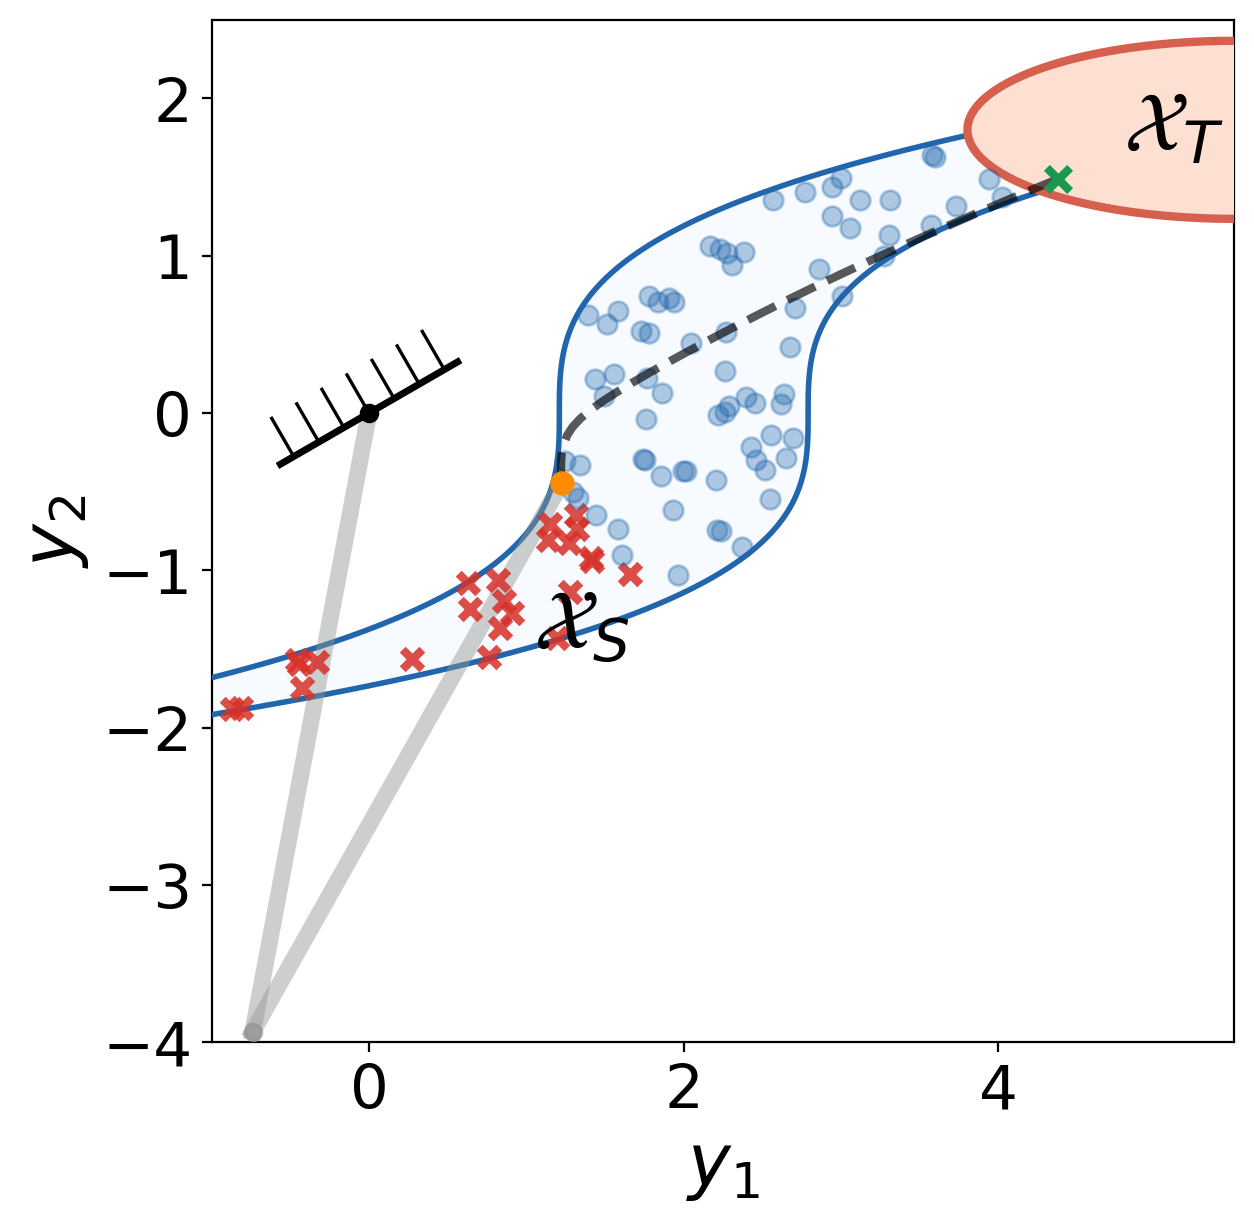

saved fig_manip_rampc


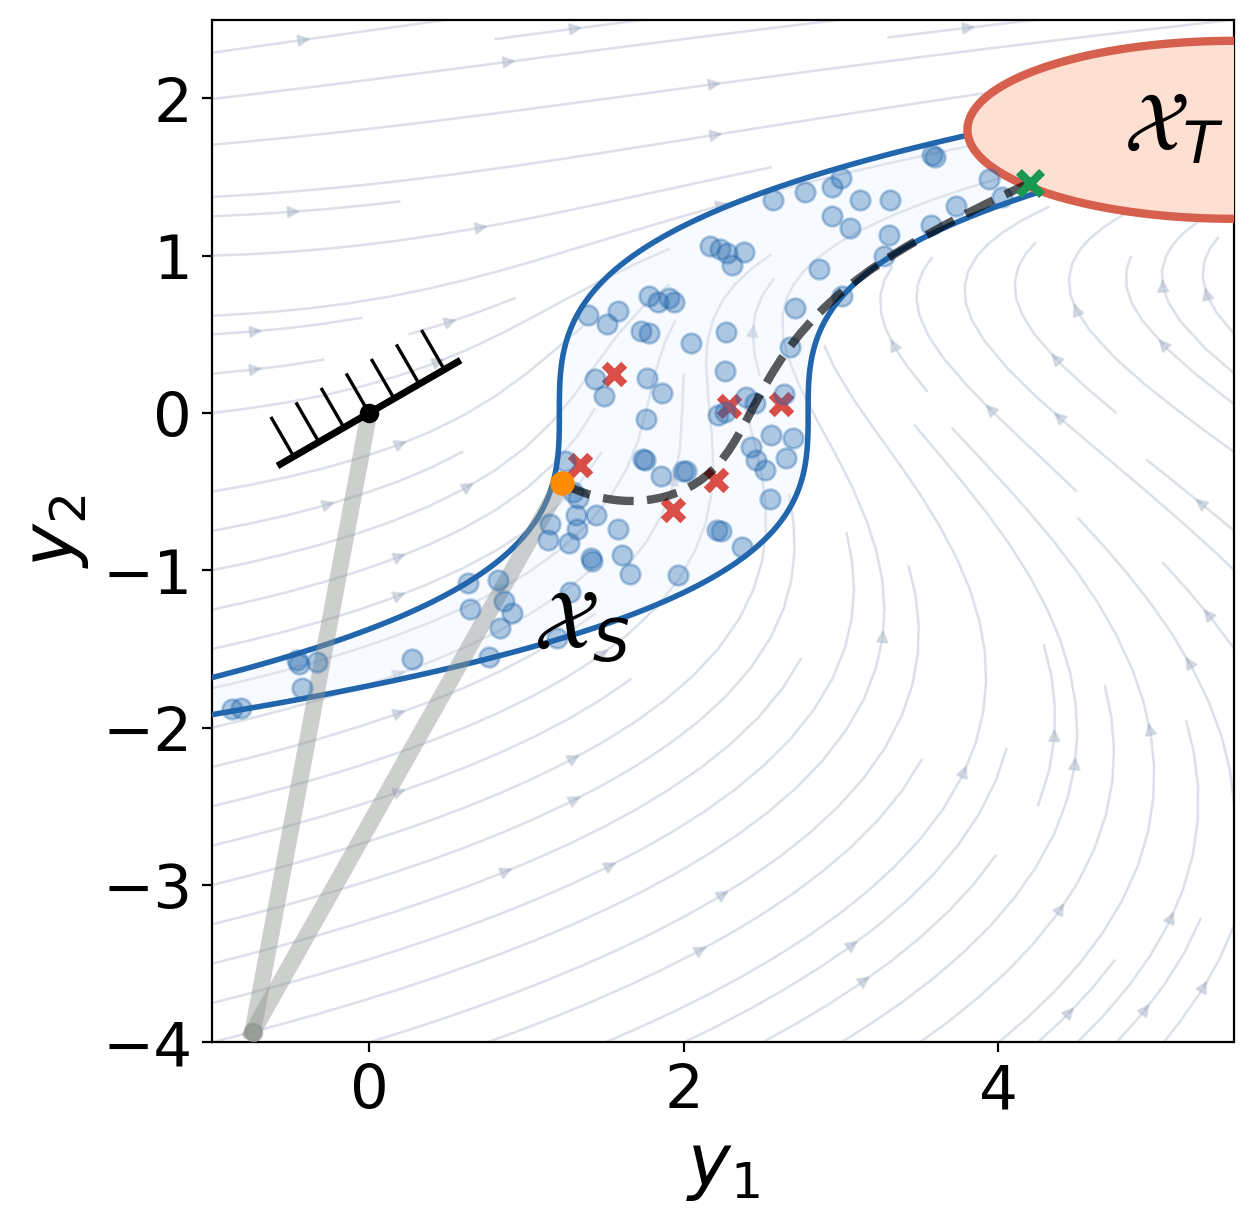

saved fig_manip_uncon


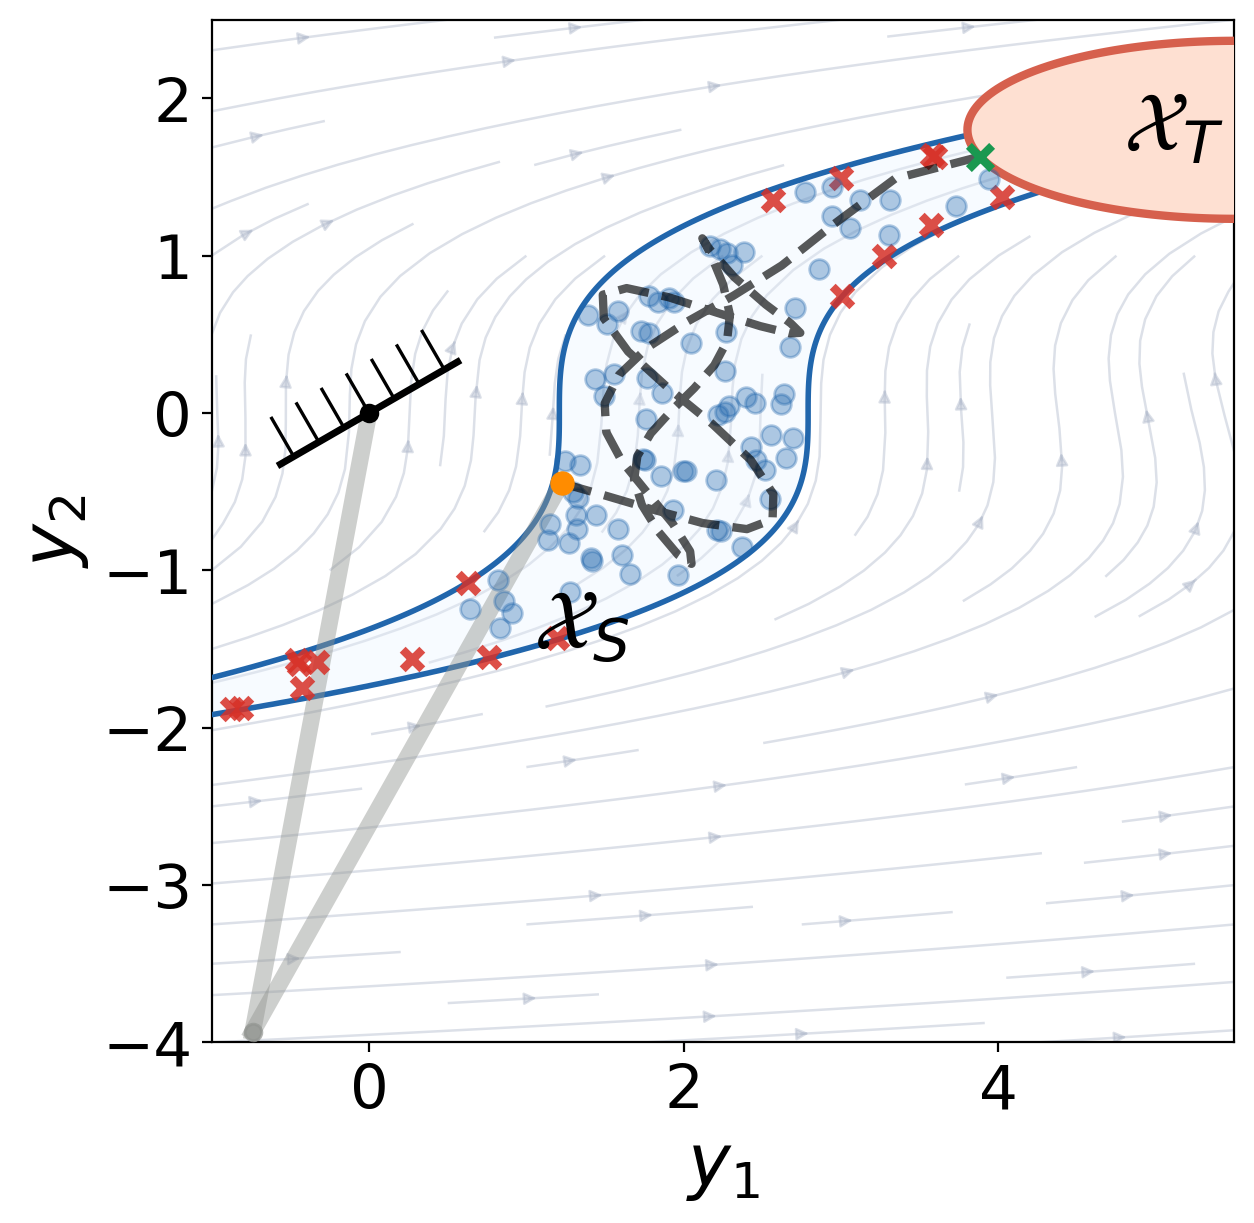

In [40]:
# -- Per-method figures: feasible region (y-space) + shared-x0 trajectory + k1 field
# Paper figure style (per-method panels + combined comparison);
# k1(y) vector field mirrors notebooks/make_paper_figs_dubins.ipynb
px = 1 / plt.rcParams["figure.dpi"]
FS_P = 30
C_ARM = (146 / 255, 149 / 255, 145 / 255)  # BetterColor.gray2
C_START = (1.0, 0.549, 0.0)  # BetterColor.orange3
C_END = (0.102, 0.596, 0.314)  # BetterColor.green0
C_GRAY = (178 / 255, 187 / 255, 205 / 255, 0.45)  # BetterColor.gray0(0.45) -- k1 field

_g1 = np.linspace(-1.0, 5.5, 400)
_g2 = np.linspace(-4.0, 2.5, 400)
G1, G2 = np.meshgrid(_g1, _g2)
Zpsi, Zphi = psi_y_func(G1, G2), phi_y_func(G1, G2)

# k1(y) vector-field grid over the output-space view
n_vf = 22
vf_y1 = np.linspace(-1.0, 5.5, n_vf)
vf_y2 = np.linspace(-4.0, 2.5, n_vf)
VF_Y1, VF_Y2 = np.meshgrid(vf_y1, vf_y2)


def _k1_field(ax, k1opt):
    f = sp.lambdify([y1, y2], list(k1opt), "numpy")
    vals = f(VF_Y1, VF_Y2)
    U = np.broadcast_to(np.asarray(vals[0], float), VF_Y1.shape).astype(float)
    V = np.broadcast_to(np.asarray(vals[1], float), VF_Y1.shape).astype(float)
    ax.streamplot(
        vf_y1,
        vf_y2,
        U,
        V,
        color=C_GRAY,
        linewidth=0.9,
        density=0.9,
        arrowsize=0.9,
        zorder=1,
    )


def draw_sets(ax):
    ax.contourf(
        G1, G2, Zpsi, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=2
    )
    ax.contour(G1, G2, Zpsi, levels=[0], colors=["#2166ac"], linewidths=2, zorder=3)
    ax.contourf(
        G1, G2, Zphi, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=4
    )
    ax.contour(G1, G2, Zphi, levels=[0], colors=["#d6604d"], linewidths=3, zorder=5)


def draw_robot(ax, x0):
    q1, q2 = float(x0[0]), float(x0[1])
    jx, jy = l1 * np.cos(q1), l1 * np.sin(q1)
    ex, ey = jx + l2 * np.cos(q1 + q2), jy + l2 * np.sin(q1 + q2)
    ax.plot([0, jx], [0, jy], "o-", alpha=0.45, lw=6, color=C_ARM, zorder=6)
    ax.plot([jx, ex], [jy, ey], "o-", alpha=0.45, lw=6, color=C_ARM, zorder=6)
    wall_hw, tick_len, n_ticks = 0.65, 0.28, 7
    th = np.radians(30)
    wd = np.array([np.cos(th), np.sin(th)])
    wp = np.array([-np.sin(th), np.cos(th)])
    p0, p1 = -wall_hw * wd, wall_hw * wd
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "k-", lw=2.5, zorder=50)
    for sv in np.linspace(-wall_hw * 0.85, wall_hw * 0.85, n_ticks):
        b = sv * wd
        tp = b + tick_len * wp
        ax.plot([b[0], tp[0]], [b[1], tp[1]], "k-", lw=1.2, zorder=50)
    ax.plot(0, 0, "ko", markersize=6, zorder=51)


FIG = {
    "Vanilla MPC": ("fig_manip_vanilla", None),
    "RA-MPC": ("fig_manip_rampc", k1_ra),
    "Unconstrained": ("fig_manip_uncon", k1_unc),
}
for method, (fname, k1opt) in FIG.items():
    mask = feas[method]
    yF1, yF2 = y1_samp[candidate_idx[mask]], y2_samp[candidate_idx[mask]]
    yI1, yI2 = y1_samp[candidate_idx[~mask]], y2_samp[candidate_idx[~mask]]
    _, _, xt = TRAJ[method]
    yt = np.array([hx_func(*xx).flatten() for xx in xt])
    fig, ax = plt.subplots(figsize=(650 * px, 600 * px), layout="constrained")
    fig.set_dpi(200)
    if k1opt is not None:
        _k1_field(ax, k1opt)
    draw_sets(ax)
    draw_robot(ax, x0_shared)
    ax.scatter(
        yI1,
        yI2,
        s=50,
        color="#d73027",
        alpha=0.85,
        marker="x",
        linewidths=3,
        label=f"infeasible: {int((~mask).sum())}",
        zorder=8,
    )
    ax.scatter(
        yF1,
        yF2,
        s=50,
        color="#2166ac",
        alpha=0.35,
        marker="o",
        label=f"feasible: {int(mask.sum())}",
        zorder=9,
    )
    ax.plot(
        yt[:, 0], yt[:, 1], color="black", lw=3, alpha=0.65, linestyle="--", zorder=10
    )
    ax.scatter(
        [yt[0, 0]], [yt[0, 1]], s=70, c=[C_START], marker="o", linewidths=0.4, zorder=20
    )
    ax.scatter(
        [yt[-1, 0]], [yt[-1, 1]], s=70, c=[C_END], marker="x", linewidths=3, zorder=20
    )
    ax.text(1.05, -1.5, r"$\mathcal{X}_S$", zorder=100, fontsize=FS_P)
    ax.text(4.8, 1.67, r"$\mathcal{X}_T$", zorder=100, fontsize=FS_P)
    ax.set_xlabel("$y_1$", fontsize=FS_P - 4)
    ax.set_ylabel("$y_2$", fontsize=FS_P - 4)
    ax.xaxis.set_tick_params(labelsize=22)
    ax.yaxis.set_tick_params(labelsize=22)
    ax.set_xlim(-1.0, 5.5)
    ax.set_ylim(-4.0, 2.5)
    ax.set_aspect("equal")
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(OUTDIR, f"{fname}.{ext}"), dpi=200)
    print("saved", fname)
    plt.show()

In [41]:
# -- RA-MPC success rate vs sampling time dt (fixed dt*N = 0.2 s) — cached -----
sweep_idx = candidate_idx[:N_SWEEP_CAND]


def _sweep_sig():
    import hashlib

    parts = [
        "v1",
        N_SWEEP_CAND,
        SEED,
        T_HOR,
        T_MAX,
        tuple(DT_SWEEP),
        u1_max,
        u2_max,
        int(
            os.path.getmtime(
                os.path.join(
                    ROOT, "controllers", "sop_bounded_control_acrobot_result.py"
                )
            )
        ),
    ]
    return hashlib.md5(repr(parts).encode()).hexdigest()


_scache = os.path.join(OUTDIR, "dt_sweep_manip_cache.npz")
sweep_rho = None
if (not RECOMPUTE_FEAS) and os.path.exists(_scache):
    d = np.load(_scache)
    if str(d["sig"]) == _sweep_sig():
        sweep_dt, sweep_rho = d["dt"], d["rho"]
        print("loaded cached dt sweep")

if sweep_rho is None:
    print(
        f"computing RA-MPC dt sweep over {len(sweep_idx)} candidates (slow) ...",
        flush=True,
    )
    sweep_dt, sweep_rho = [], []
    for dt in DT_SWEEP:
        N = int(round(T_HOR / dt))
        solver = make_fast_solver(dt, N, "cert")
        m = np.array(
            [
                feas_rampc(x_samples[:, i], solver=solver, dt=dt, T_max=T_MAX)
                for i in sweep_idx
            ],
            dtype=bool,
        )
        rho = 100.0 * m.sum() / len(sweep_idx)
        sweep_dt.append(dt)
        sweep_rho.append(rho)
        print(f"  dt={dt:.3f}  N={N:2d}  rho={rho:.1f}%", flush=True)
    sweep_dt, sweep_rho = np.array(sweep_dt), np.array(sweep_rho)
    np.savez(_scache, sig=_sweep_sig(), dt=sweep_dt, rho=sweep_rho)

loaded cached dt sweep


saved fig_manip_compare


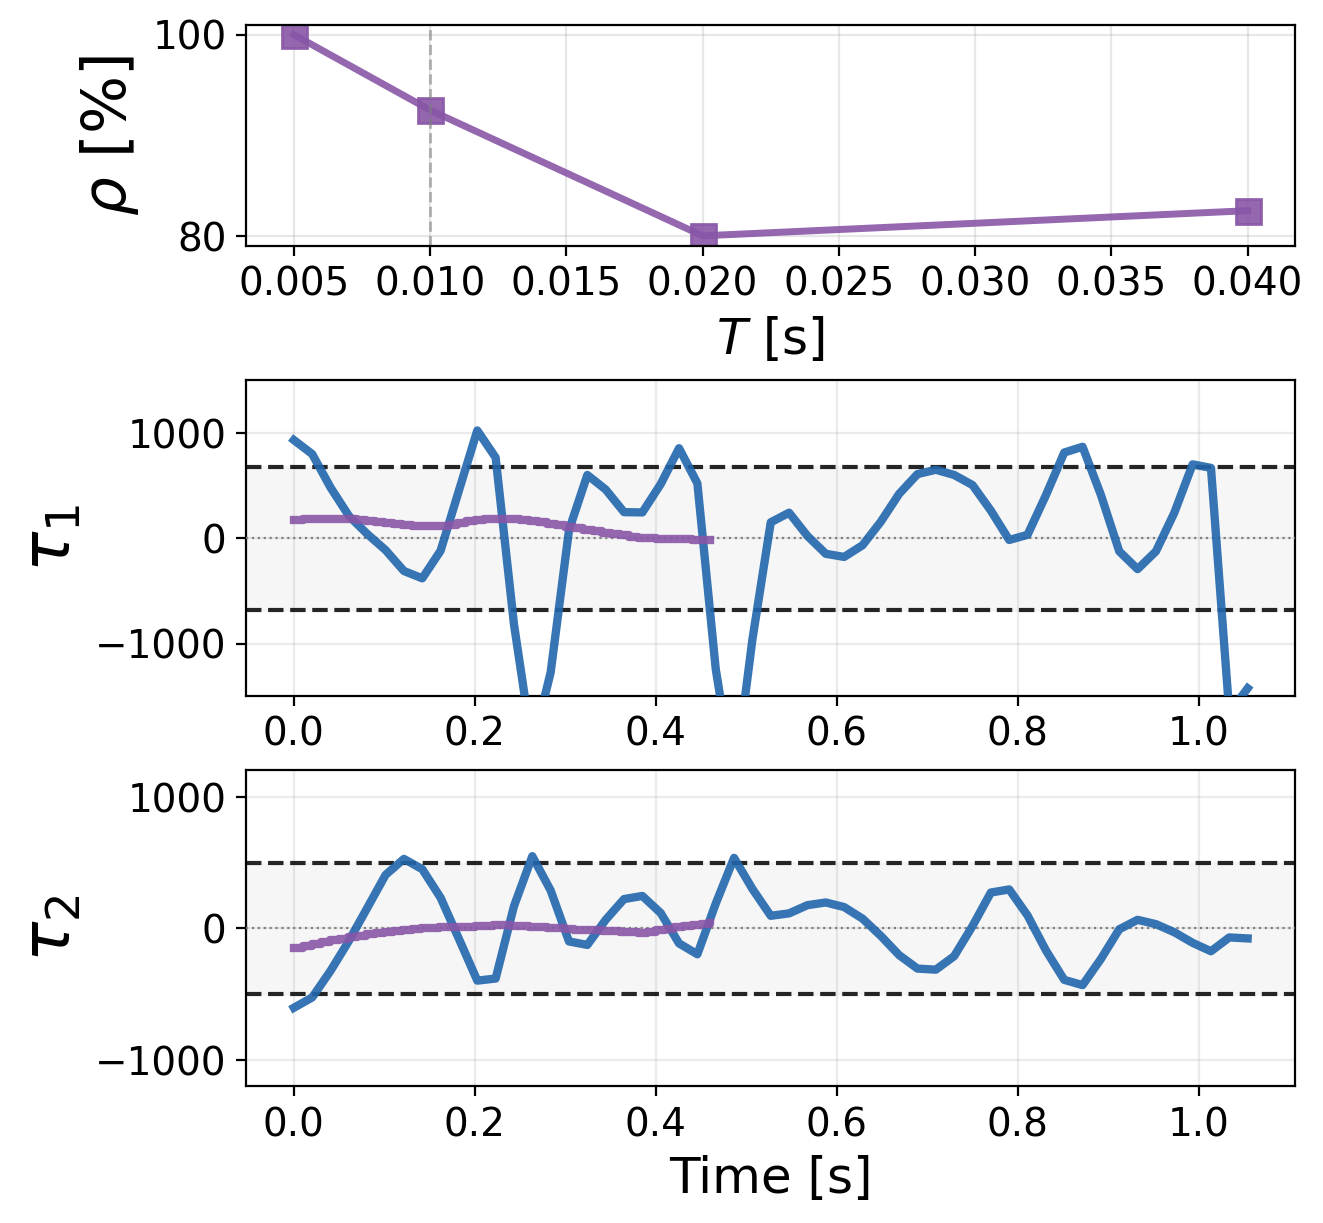

In [42]:
# -- Combined figure: dt-sweep success rate (top) + torque comparison ---------
# Paper figure style (per-method panels + combined comparison)
tu, uu_u, _ = TRAJ["Unconstrained"]
tr, uu_r, _ = TRAJ["RA-MPC"]
col_unc, col_ra = "#2166ac", "#8856a7"
FS_C = 24

fig, (axR, axW, axA) = plt.subplots(
    3,
    1,
    figsize=(650 * px, 600 * px),
    layout="constrained",
    gridspec_kw={"height_ratios": [0.7, 1.0, 1.0]},
)
fig.set_dpi(200)

axR.plot(sweep_dt, sweep_rho, color=col_ra, marker="s", lw=2.5, ms=9, alpha=0.9)
axR.axvline(DT_BASE, color="gray", lw=1, ls="--", alpha=0.6)
axR.set_xlabel("$T$ [s]", fontsize=FS_C - 6)
axR.set_ylabel(r"$\rho$ [%]", fontsize=FS_C - 2)
axR.xaxis.set_tick_params(labelsize=14)
axR.yaxis.set_tick_params(labelsize=14)
axR.grid(True, alpha=0.3)


# y-limits frame the in-bound RA-MPC step vs the unconstrained excursion; tune to your data
YLIM = {0: (-1500, 1500), 1: (-1200, 1200)}
for ax, ch, ub, lbl in zip(
    (axW, axA), (0, 1), (u1_max, u2_max), (r"$\tau_1$", r"$\tau_2$")
):
    ax.axhspan(-ub, ub, color="#f0f0f0", alpha=0.6, zorder=0)
    ax.axhline(ub, color="black", lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(-ub, color="black", lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(0, color="gray", lw=0.8, ls=":", zorder=4)
    ax.plot(
        tu,
        uu_u[:, ch],
        color=col_unc,
        lw=3,
        alpha=0.9,
        zorder=10,
        label="unconstrained",
    )
    if len(uu_r) > 0:
        ax.step(
            tr[:-1],
            uu_r[:, ch],
            where="post",
            color=col_ra,
            lw=3,
            alpha=0.9,
            zorder=10,
            label="RA-MPC (ours)",
        )
    ax.set_ylabel(lbl, fontsize=FS_C)
    ax.set_ylim(*YLIM[ch])
    ax.xaxis.set_tick_params(labelsize=14)
    ax.yaxis.set_tick_params(labelsize=14)
    ax.grid(True, alpha=0.25)
axA.set_xlabel("Time [s]", fontsize=FS_C - 6)

for ext in ("pdf", "png"):
    fig.savefig(os.path.join(OUTDIR, f"fig_manip_compare.{ext}"), dpi=200)
print("saved fig_manip_compare")
plt.show()

## Summary

Saved to `figures/` (each `.pdf` + `.png`): `fig_manip_vanilla`, `fig_manip_rampc`,
`fig_manip_uncon` (per-method feasible region + shared-x0 trajectory) and
`fig_manip_compare` (RA-MPC success rate vs sampling time + tau1/tau2 comparison).

The unconstrained controller uses the **certified region {cert>=0}** as its feasibility
(its k1 closed loop reaches the target only glacially), whereas the two MPC methods are
judged by actually reaching the target. Feasibility / dt-sweep cached under `figures/`;
set `RECOMPUTE_FEAS=True` to refresh.
